# Raman Area Scan Parser

This notebook parses every Raman `.txt` export in the current folder into a tidy table with one row per single spectrum. The parsed output is suitable for later baseline correction with `pybaselines`.

In [15]:
import importlib

import raman.config as cfg

cfg = importlib.reload(cfg)

print("Configuration module reloaded: raman/config.py")

Configuration module reloaded: raman/config.py


## Central Configuration

Edit parameters in one place by updating `raman_config.py` and re-running this configuration cell.

In [16]:
import importlib

import raman.config as cfg
from raman.pipeline import run_stage1_parse

cfg = importlib.reload(cfg)

# -----------------------------------------------------------------------------
# Stage 1: parse all exports into a shared Raman data structure
# -----------------------------------------------------------------------------
stage1 = run_stage1_parse(cfg.DATA_DIR)
TXT_FILES = stage1["txt_files"]
parsed_files = stage1["parsed_files"]
parsed_summary = stage1["parsed_summary"]
all_tidy = stage1["all_tidy"]

parsed_summary

,file,points,spectra,cube_x,cube_y,size_x,size_y,scan_width,scan_height
0,S6_hBN_1_10mW_20260505.txt,1600,100,10,10,10,10,10.0,10.0
1,S6_hBN_1_10mW_20260610.txt,1600,100,10,10,10,10,10.0,10.0
2,S6_hBN_1_10mW_20260710.txt,1600,100,10,10,10,10,10.0,10.0
3,S6_hBN_1_30mW_20260423.txt,1600,100,10,10,10,10,10.0,10.0
4,S6_hBN_2_10mW_20260319.txt,1600,100,10,10,10,10,10.0,10.0
5,S6_RO_20mW_20260319.txt,1600,100,10,10,10,10,10.0,10.0
6,S6_RO_20mW_20260505.txt,1600,100,10,10,10,10,10.0,10.0
7,S6_RO_20mW_20260610.txt,1600,100,10,10,10,10,10.0,10.0
8,S6_RO_20mW_20260710.txt,1600,100,10,10,10,10,10.0,10.0
9,S6_RO_30mW_20260423.txt,1600,100,10,10,10,10,10.0,10.0


In [17]:
import importlib

from IPython.display import Markdown, display

import raman.config as cfg
import raman.core.filters as rpu
import raman.pipeline as rnp

cfg = importlib.reload(cfg)
rpu = importlib.reload(rpu)
rnp = importlib.reload(rnp)

# -----------------------------------------------------------------------------
# Stage 2: optional pixel-level filtering in one stage
# Order: border-pixel filter -> mean-intensity spectrum gate -> max-intensity cutoff.
# Each sub-step supports group/subgroup scoping (e.g., "hBN" vs "hBN_1").
# -----------------------------------------------------------------------------
stage2 = rnp.run_stage2_pixel_filter(
    parsed_files=parsed_files,
    border_enabled=cfg.BORDER_FILTER_ENABLED,
    border_width=cfg.BORDER_FILTER_BORDER_WIDTH,
    border_apply_to_groups=cfg.BORDER_FILTER_APPLY_TO_GROUPS,
    spectrum_gate_enabled=cfg.SPECTRUM_GATE_ENABLED,
    spectrum_gate_wavenumber_region_cm1=cfg.SPECTRUM_GATE_WAVENUMBER_REGION_CM1,
    spectrum_gate_min_mean_intensity=cfg.SPECTRUM_GATE_MIN_MEAN_INTENSITY,
    spectrum_gate_apply_to_groups=cfg.SPECTRUM_GATE_APPLY_TO_GROUPS,
    max_pixel_intensity=cfg.MAX_PIXEL_INTENSITY,
    max_intensity_apply_to_groups=cfg.MAX_INTENSITY_APPLY_TO_GROUPS,
)
pixel_filtered_parsed_files = stage2["pixel_filtered_parsed_files"]
pixel_filtered_all_tidy = stage2["pixel_filtered_all_tidy"]
pixel_filtered_summary = stage2["pixel_filtered_summary"]
border_filter_report = stage2["border_filter_report"]
spectra_gate_report = stage2["spectrum_gate_report"]
max_intensity_gate_report = stage2["max_intensity_gate_report"]

display(Markdown("### Stage 2.1 Border Filter Report"))
display(border_filter_report)

display(Markdown("### Stage 2.2 Spectrum Gate Report"))
display(spectra_gate_report)

display(Markdown("### Stage 2.3 Max Intensity Gate Report"))
display(max_intensity_gate_report)

display(Markdown("### Stage 2 Combined Pixel-Filtered Summary"))
pixel_filtered_summary

### Stage 2.1 Border Filter Report

,file,group,subgroup,border_applied,border_width,spectra_total,spectra_kept,spectra_dropped,drop_fraction
0,S6_hBN_1_10mW_20260505.txt,hBN,hBN_1,True,1,100,64,36,0.36
1,S6_hBN_1_10mW_20260610.txt,hBN,hBN_1,True,1,100,64,36,0.36
2,S6_hBN_1_10mW_20260710.txt,hBN,hBN_1,True,1,100,64,36,0.36
3,S6_hBN_1_30mW_20260423.txt,hBN,hBN_1,True,1,100,64,36,0.36
4,S6_hBN_2_10mW_20260319.txt,hBN,hBN_2,False,1,100,100,0,0.00
5,S6_RO_20mW_20260319.txt,RO,RO,False,1,100,100,0,0.00
6,S6_RO_20mW_20260505.txt,RO,RO,False,1,100,100,0,0.00
7,S6_RO_20mW_20260610.txt,RO,RO,False,1,100,100,0,0.00
8,S6_RO_20mW_20260710.txt,RO,RO,False,1,100,100,0,0.00
9,S6_RO_30mW_20260423.txt,RO,RO,False,1,100,100,0,0.00


### Stage 2.2 Spectrum Gate Report

,file,group,gate_applied,window_start_cm1,window_end_cm1,threshold,spectra_total,spectra_kept,spectra_dropped,drop_fraction
0,S6_hBN_1_10mW_20260505.txt,Not applied,False,1360.0,1370.0,10000.0,100,100,0,0.0
1,S6_hBN_1_10mW_20260610.txt,Not applied,False,1360.0,1370.0,10000.0,100,100,0,0.0
2,S6_hBN_1_10mW_20260710.txt,Not applied,False,1360.0,1370.0,10000.0,100,100,0,0.0
3,S6_hBN_1_30mW_20260423.txt,Not applied,False,1360.0,1370.0,10000.0,100,100,0,0.0
4,S6_hBN_2_10mW_20260319.txt,Not applied,False,1360.0,1370.0,10000.0,100,100,0,0.0
5,S6_RO_20mW_20260319.txt,Not applied,False,1360.0,1370.0,10000.0,100,100,0,0.0
6,S6_RO_20mW_20260505.txt,Not applied,False,1360.0,1370.0,10000.0,100,100,0,0.0
7,S6_RO_20mW_20260610.txt,Not applied,False,1360.0,1370.0,10000.0,100,100,0,0.0
8,S6_RO_20mW_20260710.txt,Not applied,False,1360.0,1370.0,10000.0,100,100,0,0.0
9,S6_RO_30mW_20260423.txt,Not applied,False,1360.0,1370.0,10000.0,100,100,0,0.0


### Stage 2.3 Max Intensity Gate Report

,file,threshold,spectra_total,spectra_kept,spectra_dropped,drop_fraction
0,S6_hBN_1_10mW_20260505.txt,NaN,100,64,36,0.36
1,S6_hBN_1_10mW_20260610.txt,NaN,100,64,36,0.36
2,S6_hBN_1_10mW_20260710.txt,NaN,100,64,36,0.36
3,S6_hBN_1_30mW_20260423.txt,NaN,100,64,36,0.36
4,S6_hBN_2_10mW_20260319.txt,NaN,100,100,0,0.00
5,S6_RO_20mW_20260319.txt,NaN,100,100,0,0.00
6,S6_RO_20mW_20260505.txt,NaN,100,100,0,0.00
7,S6_RO_20mW_20260610.txt,NaN,100,100,0,0.00
8,S6_RO_20mW_20260710.txt,NaN,100,100,0,0.00
9,S6_RO_30mW_20260423.txt,NaN,100,100,0,0.00


### Stage 2 Combined Pixel-Filtered Summary

,file,points,spectra,cube_x,cube_y,size_x,size_y,scan_width,scan_height,spectra_kept,spectra_dropped,drop_fraction
0,S6_hBN_1_10mW_20260505.txt,1600,100,10,10,10,10,10.0,10.0,64,36,0.36
1,S6_hBN_1_10mW_20260610.txt,1600,100,10,10,10,10,10.0,10.0,64,36,0.36
2,S6_hBN_1_10mW_20260710.txt,1600,100,10,10,10,10,10.0,10.0,64,36,0.36
3,S6_hBN_1_30mW_20260423.txt,1600,100,10,10,10,10,10.0,10.0,64,36,0.36
4,S6_hBN_2_10mW_20260319.txt,1600,100,10,10,10,10,10.0,10.0,100,0,0.00
5,S6_RO_20mW_20260319.txt,1600,100,10,10,10,10,10.0,10.0,100,0,0.00
6,S6_RO_20mW_20260505.txt,1600,100,10,10,10,10,10.0,10.0,100,0,0.00
7,S6_RO_20mW_20260610.txt,1600,100,10,10,10,10,10.0,10.0,100,0,0.00
8,S6_RO_20mW_20260710.txt,1600,100,10,10,10,10,10.0,10.0,100,0,0.00
9,S6_RO_30mW_20260423.txt,1600,100,10,10,10,10,10.0,10.0,100,0,0.00


In [18]:
import importlib

import raman.config as cfg
import raman.pipeline as rnp

cfg = importlib.reload(cfg)
rnp = importlib.reload(rnp)

# -----------------------------------------------------------------------------
# Stage 3: low-wavenumber filtering (no pixel cutting in this step).
# -----------------------------------------------------------------------------
stage3 = rnp.run_stage3_low_wavenumber_filter(
    parsed_files=pixel_filtered_parsed_files,
    min_wavenumber_cm1=cfg.MIN_WAVENUMBER_CM1,
)
low_wavenumber_parsed_files = stage3["low_wavenumber_parsed_files"]
low_wavenumber_all_tidy = stage3["low_wavenumber_all_tidy"]
low_wavenumber_summary = stage3["low_wavenumber_summary"]

low_wavenumber_summary

,file,points,spectra,cube_x,cube_y,size_x,size_y,scan_width,scan_height,min_wavenumber
0,S6_hBN_1_10mW_20260505.txt,1539,100,10,10,10,10,10.0,10.0,76.7070
1,S6_hBN_1_10mW_20260610.txt,1539,100,10,10,10,10,10.0,10.0,76.7070
2,S6_hBN_1_10mW_20260710.txt,1539,100,10,10,10,10,10.0,10.0,76.6044
3,S6_hBN_1_30mW_20260423.txt,1539,100,10,10,10,10,10.0,10.0,76.2972
4,S6_hBN_2_10mW_20260319.txt,1539,100,10,10,10,10,10.0,10.0,76.4057
5,S6_RO_20mW_20260319.txt,1539,100,10,10,10,10,10.0,10.0,76.4057
6,S6_RO_20mW_20260505.txt,1539,100,10,10,10,10,10.0,10.0,76.7070
7,S6_RO_20mW_20260610.txt,1539,100,10,10,10,10,10.0,10.0,76.7070
8,S6_RO_20mW_20260710.txt,1539,100,10,10,10,10,10.0,10.0,76.6044
9,S6_RO_30mW_20260423.txt,1539,100,10,10,10,10,10.0,10.0,76.2972


In [19]:
import importlib

from IPython.display import display

import raman.config as cfg
import raman.pipeline as rnp
from raman.core.analysis import rank_despike_aggressiveness

cfg = importlib.reload(cfg)
rnp = importlib.reload(rnp)

# -----------------------------------------------------------------------------
# Stage 4: despike spectra (cosmic-ray artifact suppression).
# -----------------------------------------------------------------------------
stage4 = rnp.run_stage4_despike(
    parsed_files=low_wavenumber_parsed_files,
    neigh=cfg.DESPIKE_NEIGH,
    threshold=cfg.DESPIKE_THRESHOLD,
)
pre_despike_parsed_files = stage4["pre_despike_parsed_files"]
despiked_parsed_files = stage4["despiked_parsed_files"]
despiked_summary = stage4["despiked_summary"]
stage4_max_intensity_gate_report = stage4["max_intensity_gate_report"]

top_despike_ranked = rank_despike_aggressiveness(
    original_collection=pre_despike_parsed_files,
    despiked_collection=despiked_parsed_files,
    top_n=cfg.TOP_N_AGGRESSIVE_DESPIKE,
)

display(despiked_summary)
display(top_despike_ranked)

,file,points,spectra,cube_x,cube_y,size_x,size_y,scan_width,scan_height,spectra_kept,spectra_dropped,drop_fraction
0,S6_hBN_1_10mW_20260505.txt,1539,100,10,10,10,10,10.0,10.0,64,36,0.36
1,S6_hBN_1_10mW_20260610.txt,1539,100,10,10,10,10,10.0,10.0,64,36,0.36
2,S6_hBN_1_10mW_20260710.txt,1539,100,10,10,10,10,10.0,10.0,64,36,0.36
3,S6_hBN_1_30mW_20260423.txt,1539,100,10,10,10,10,10.0,10.0,64,36,0.36
4,S6_hBN_2_10mW_20260319.txt,1539,100,10,10,10,10,10.0,10.0,100,0,0.00
5,S6_RO_20mW_20260319.txt,1539,100,10,10,10,10,10.0,10.0,100,0,0.00
6,S6_RO_20mW_20260505.txt,1539,100,10,10,10,10,10.0,10.0,100,0,0.00
7,S6_RO_20mW_20260610.txt,1539,100,10,10,10,10,10.0,10.0,100,0,0.00
8,S6_RO_20mW_20260710.txt,1539,100,10,10,10,10,10.0,10.0,100,0,0.00
9,S6_RO_30mW_20260423.txt,1539,100,10,10,10,10,10.0,10.0,100,0,0.00


,map_index,file,row_index,col_index,max_abs_change,mean_abs_change


In [20]:
import importlib

from IPython.display import display

import raman.config as cfg
import raman.core.baseline as rbl
import raman.core.filters as rpu
import raman.pipeline as rnp

cfg = importlib.reload(cfg)
rbl = importlib.reload(rbl)
rpu = importlib.reload(rpu)
rnp = importlib.reload(rnp)

# -----------------------------------------------------------------------------
# Stage 5: baseline correction on despiked spectra
# Methods: "mor", "airpls", "poly", "rolling_ball", or "noiseaware".
# -----------------------------------------------------------------------------
stage5 = rnp.run_stage5_baseline(
    parsed_files=despiked_parsed_files,
    baseline_method=cfg.BASELINE_METHOD,
    mor_half_window=cfg.MOR_HALF_WINDOW,
    mor_window_kwargs=cfg.MOR_WINDOW_KWARGS,
    airpls_kwargs=cfg.AIRPLS_KWARGS,
    poly_kwargs=cfg.POLY_KWARGS,
    poly_mask_regions=cfg.POLY_MASK_REGIONS,
    rolling_ball_kwargs=cfg.ROLLING_BALL_KWARGS,
    noiseaware_kwargs=cfg.NOISEAWARE_KWARGS,
    noiseaware_peak_regions=cfg.NOISEAWARE_PEAK_REGIONS,
)
corrected_parsed_files = stage5["corrected_parsed_files"]
corrected_summary = stage5["corrected_summary"]

display(corrected_summary)

,file,anchors_used_min,anchors_used_max,points,min_corrected,max_corrected
0,S6_hBN_1_10mW_20260505.txt,4.0,6.0,1539,-34.975339,1286.468954
1,S6_hBN_1_10mW_20260610.txt,4.0,6.0,1539,-75.044372,3148.626631
2,S6_hBN_1_10mW_20260710.txt,5.0,7.0,1539,-55.174826,1948.770918
3,S6_hBN_1_30mW_20260423.txt,6.0,6.0,1539,-211.178042,13620.055809
4,S6_hBN_2_10mW_20260319.txt,4.0,6.0,1539,-29.302298,2017.562271
5,S6_RO_20mW_20260319.txt,4.0,6.0,1539,-62.929517,2908.788304
6,S6_RO_20mW_20260505.txt,6.0,6.0,1539,-74.549458,4232.803497
7,S6_RO_20mW_20260610.txt,4.0,6.0,1539,-43.660597,1634.604629
8,S6_RO_20mW_20260710.txt,6.0,6.0,1539,-129.487958,9054.392487
9,S6_RO_30mW_20260423.txt,6.0,7.0,1539,-89.589535,4100.129348


## Stage 6: Average Spectrum by Map (Au vs hBN)

Each Raman map is reduced to one spectrum by averaging over retained map pixels. Spectra are split into Au and hBN groups, sorted by acquisition date from filename, and plotted before/after normalization.

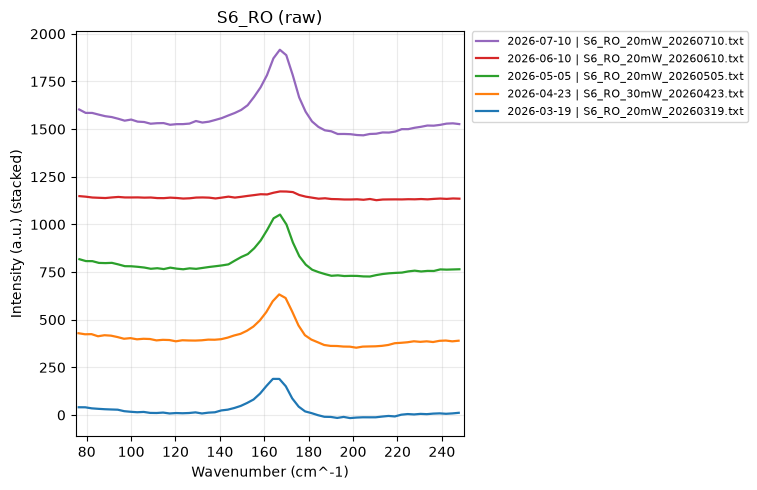

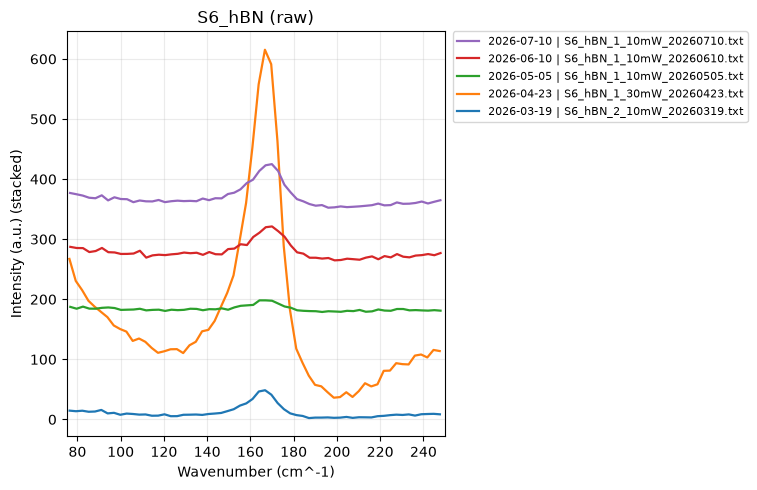

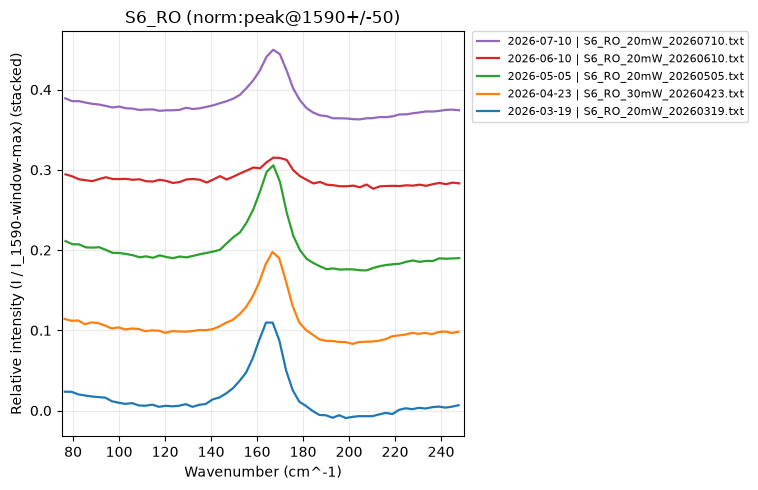

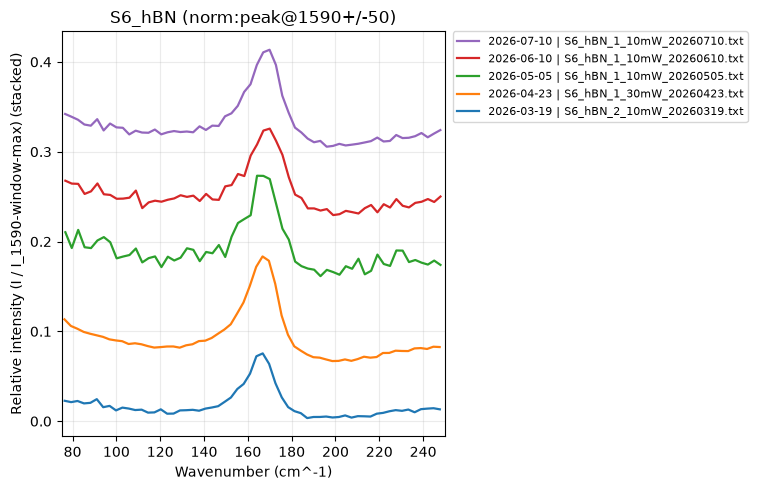

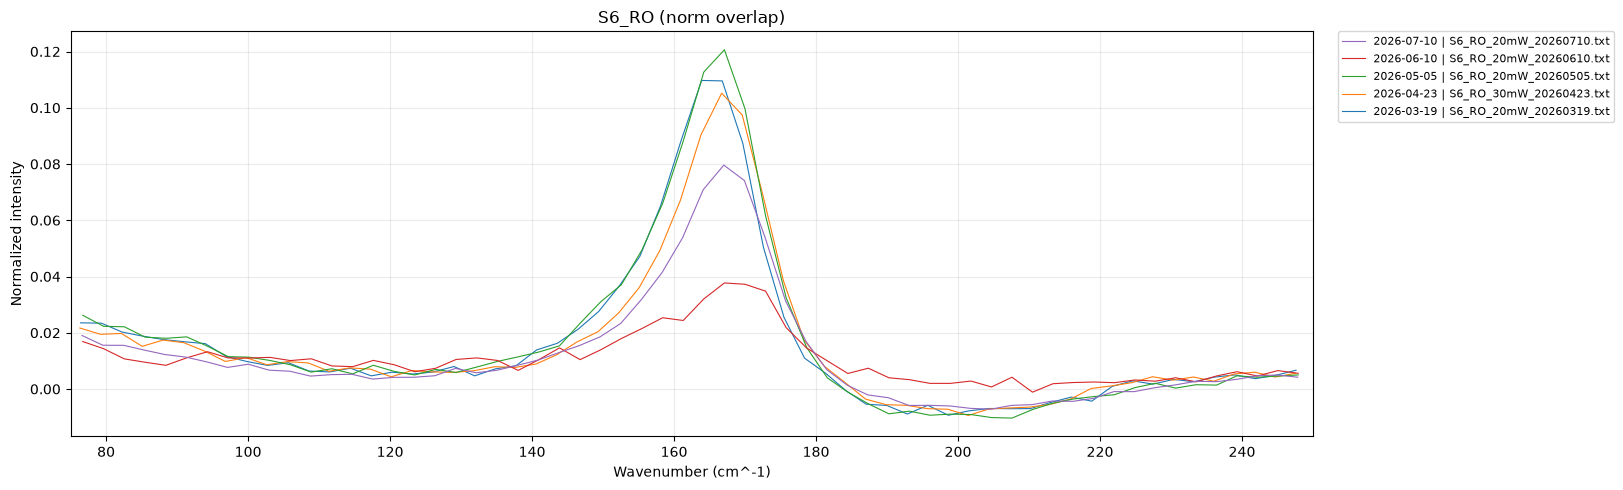

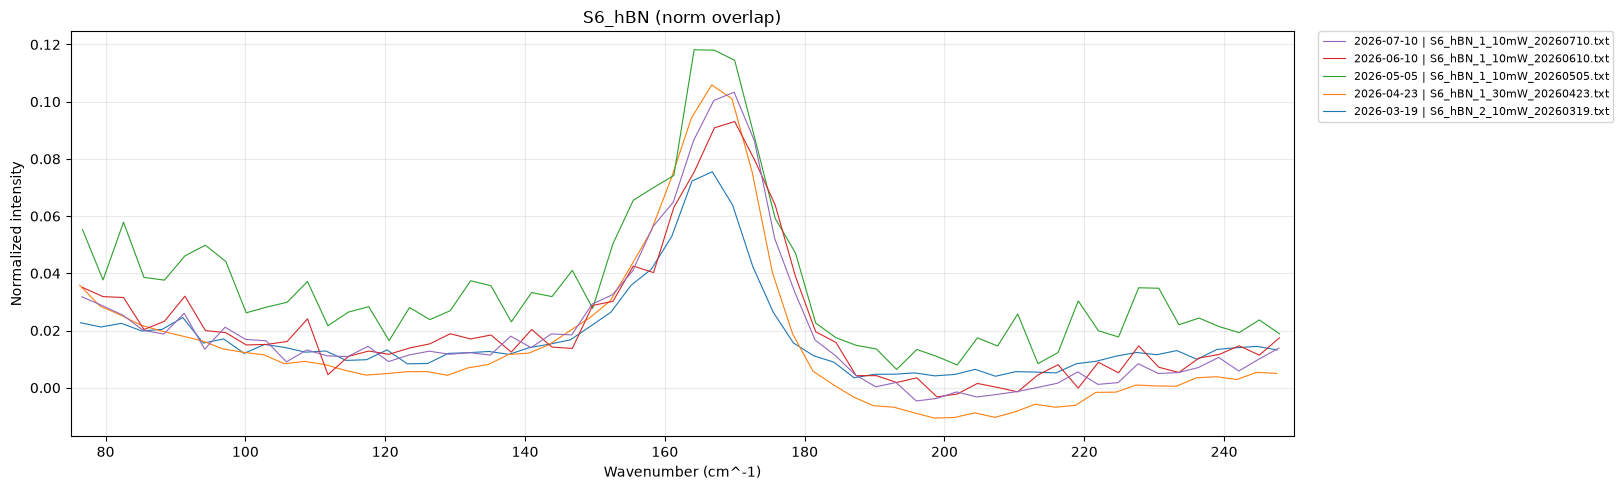

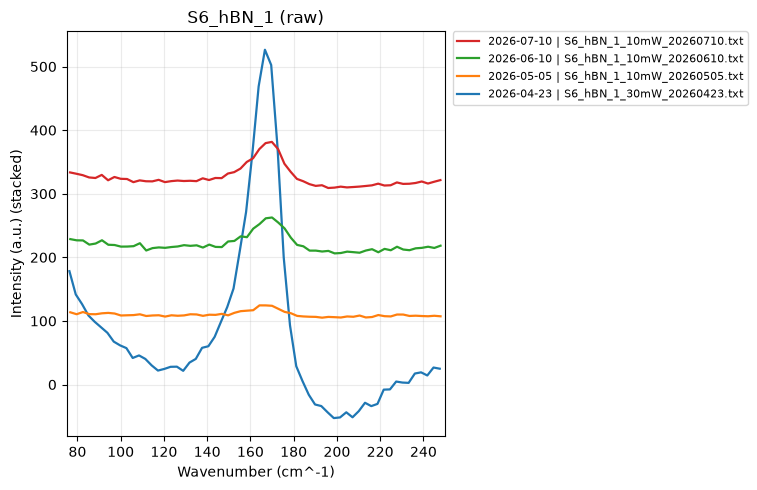

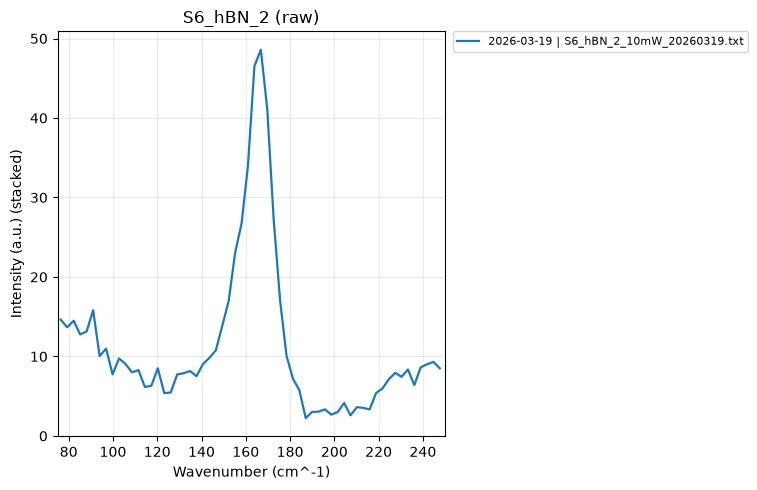

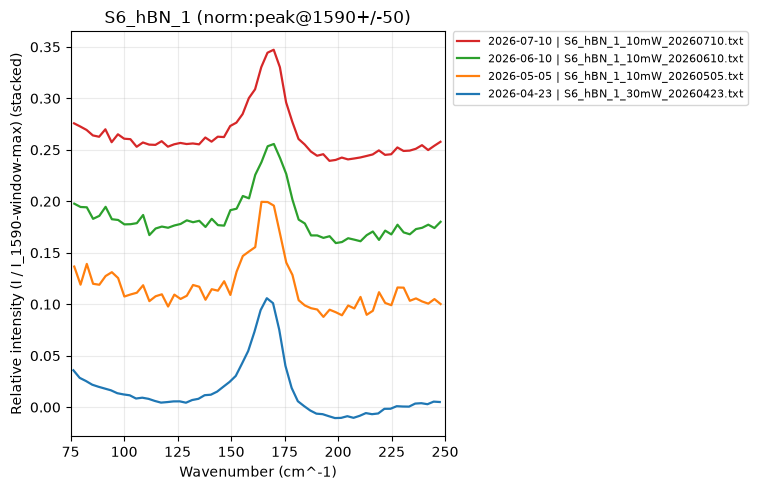

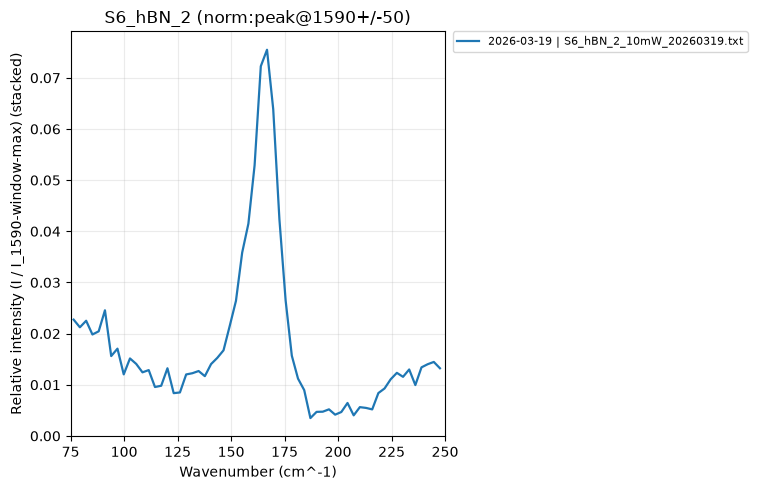

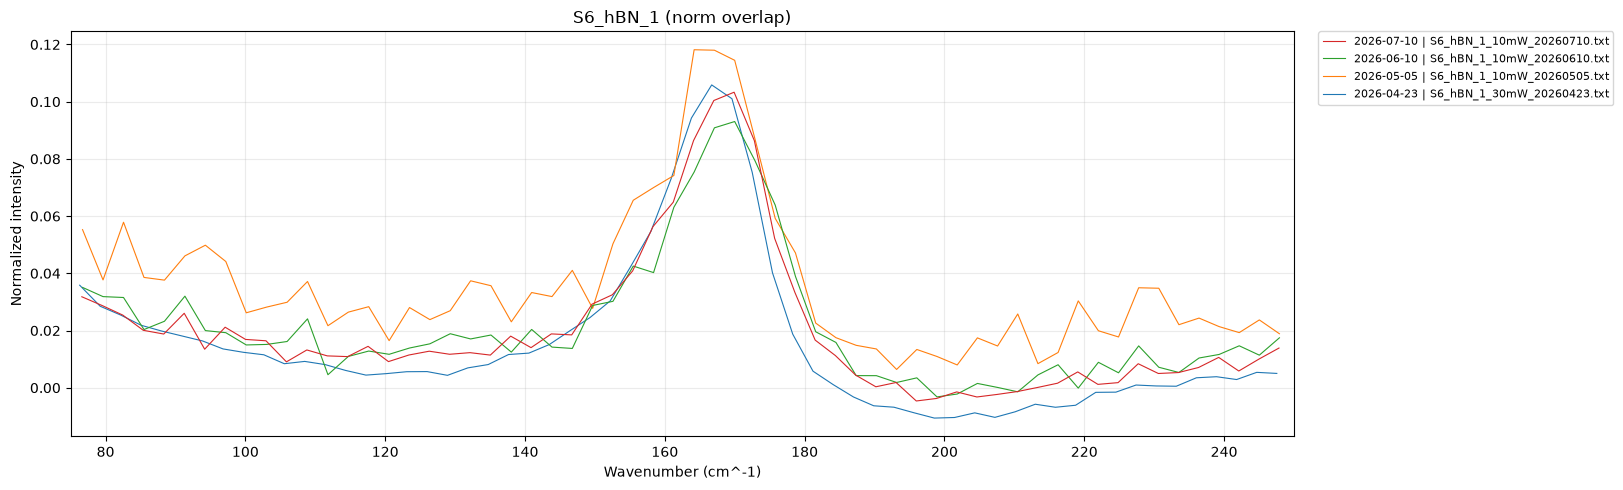

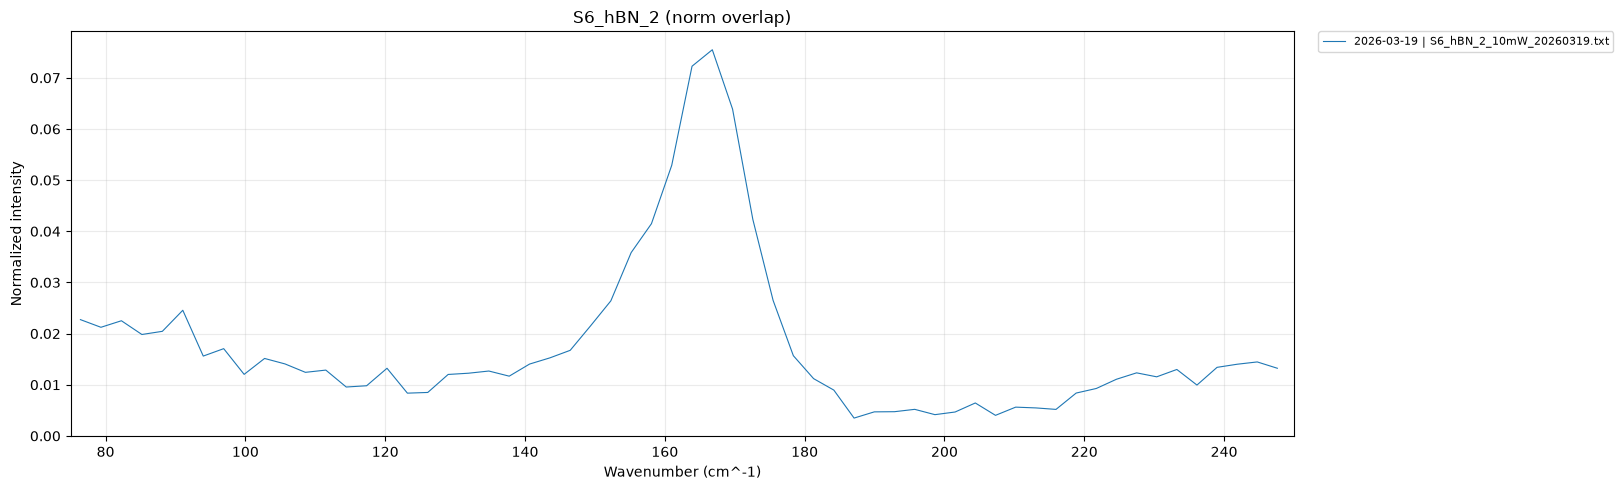

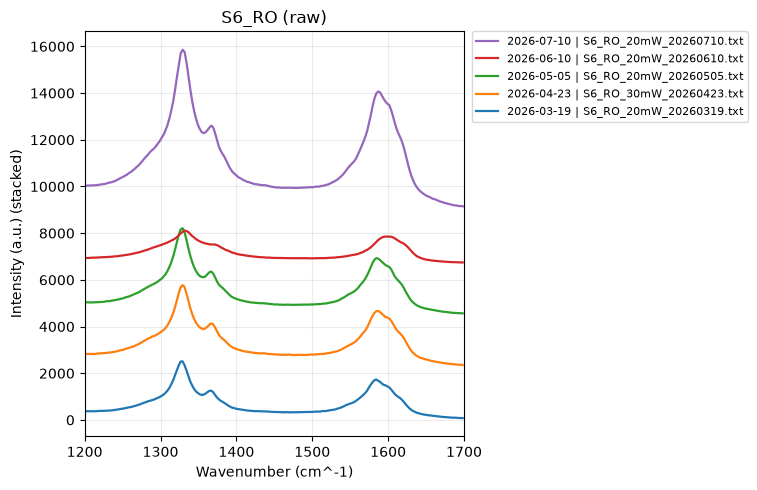

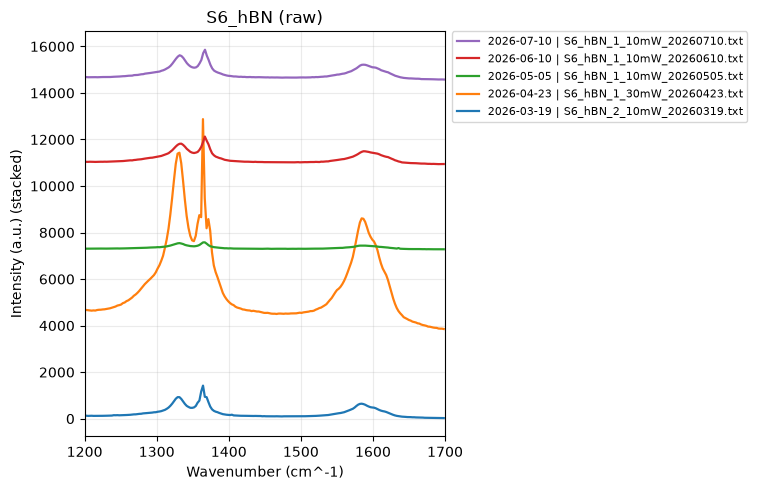

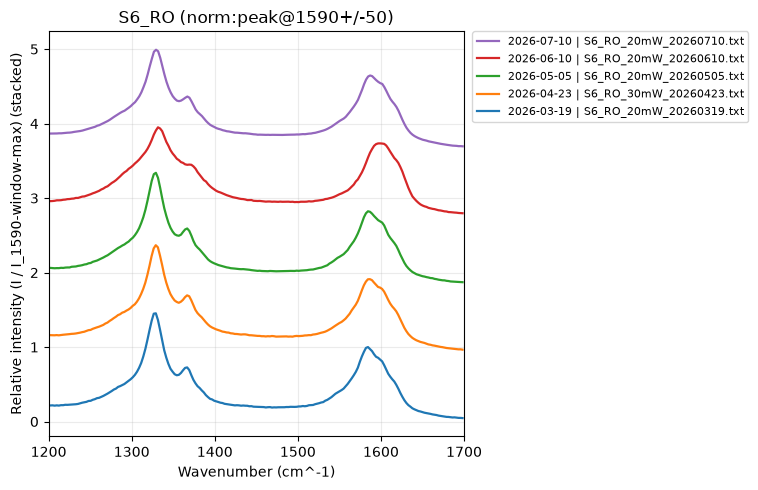

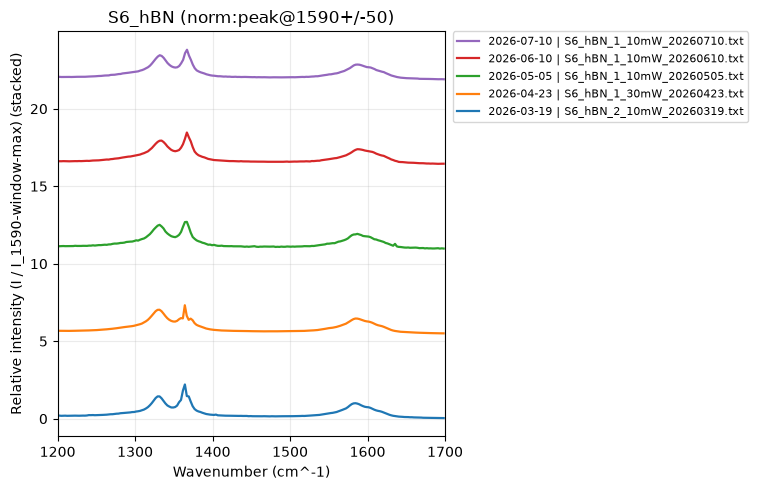

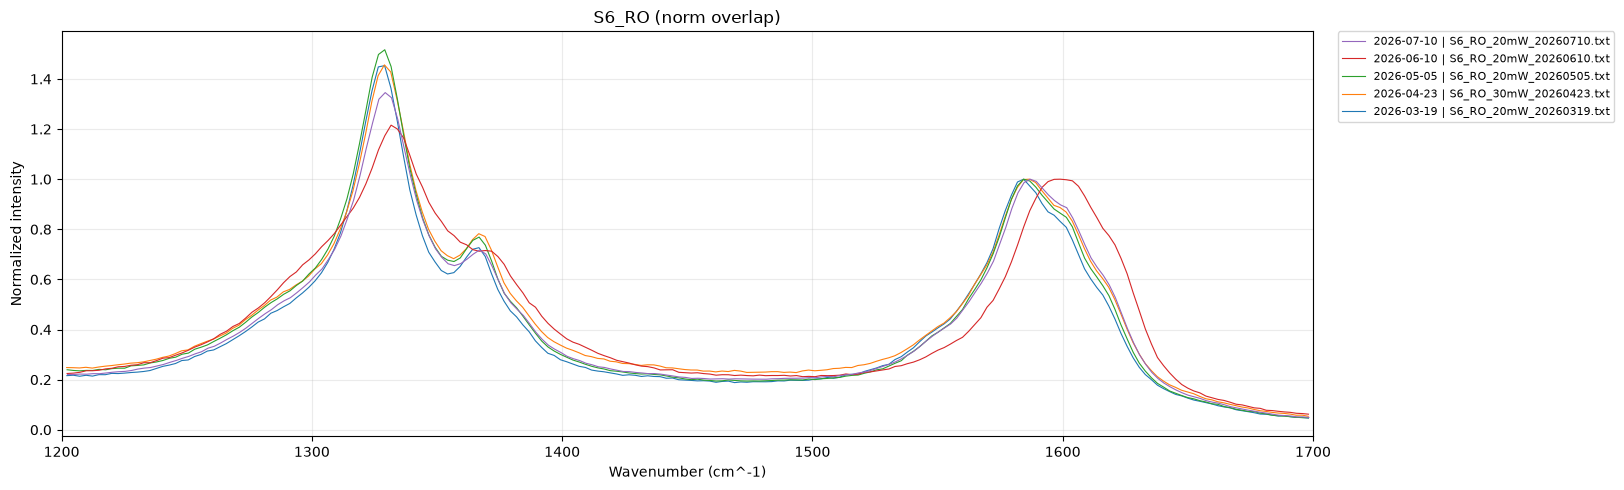

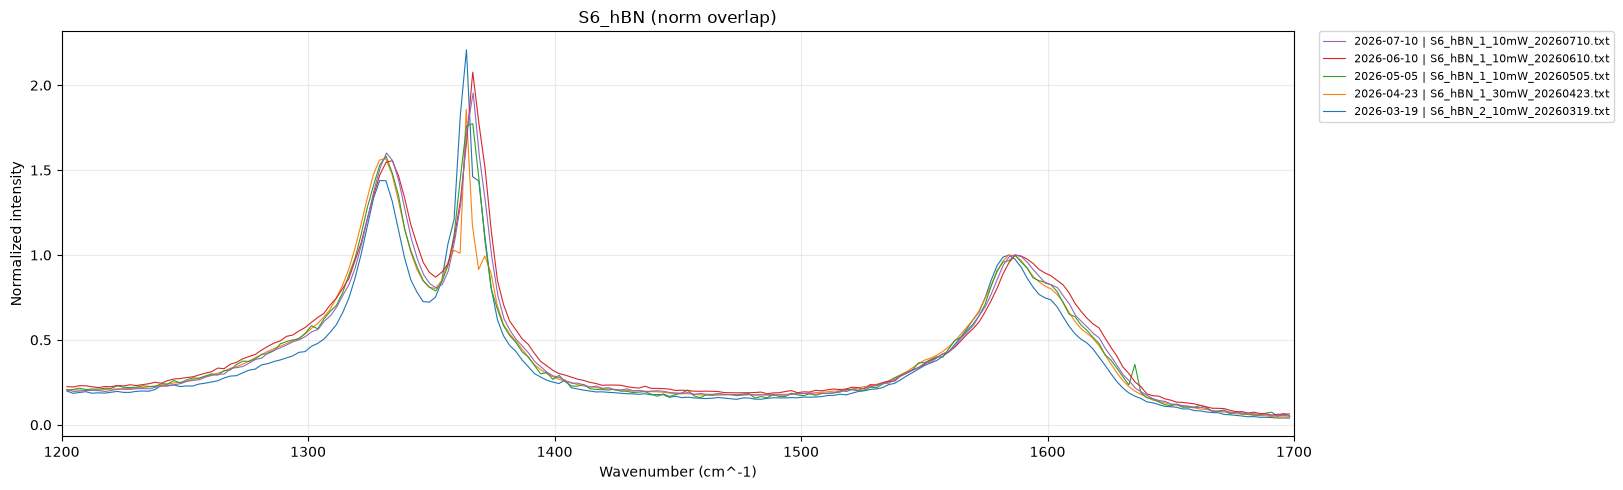

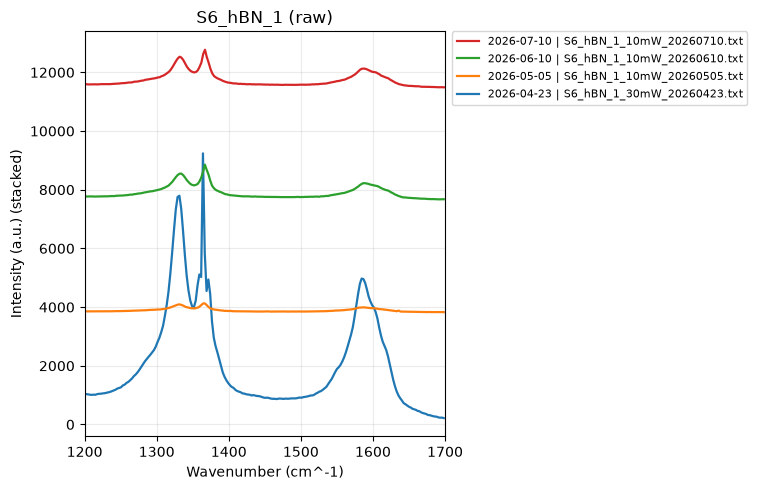

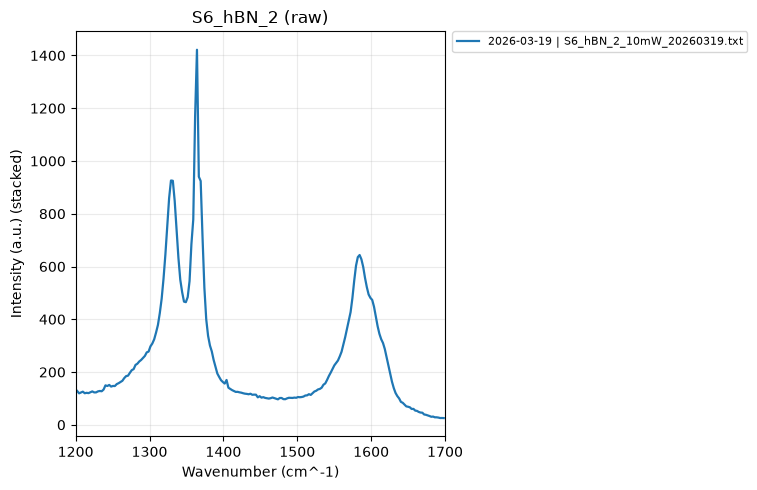

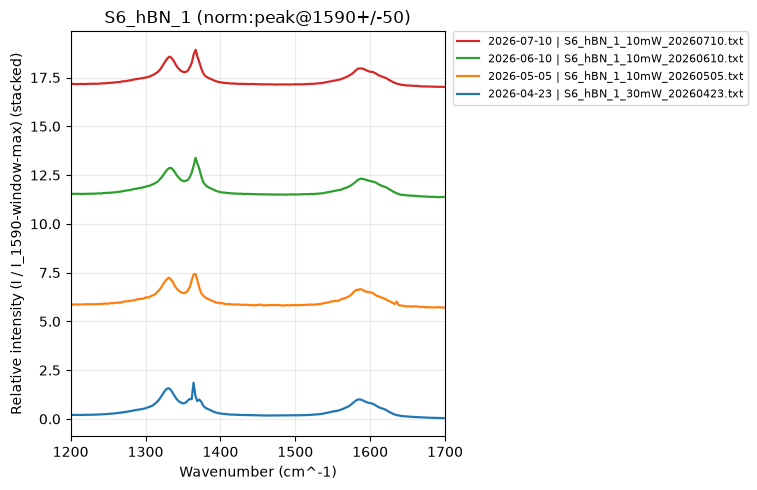

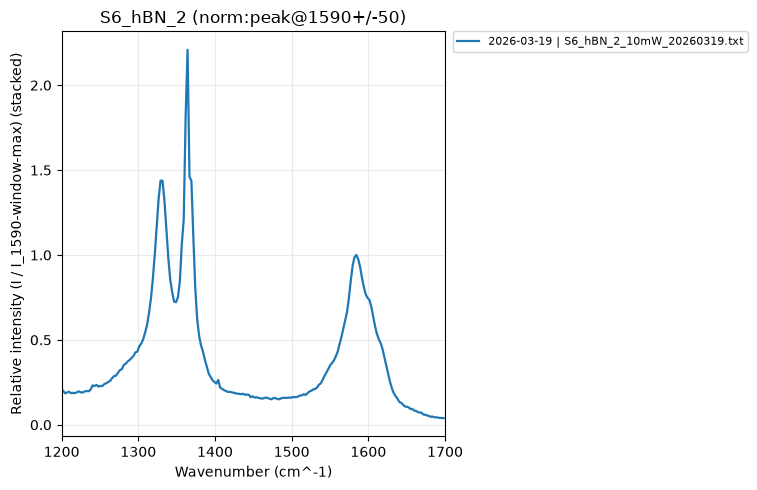

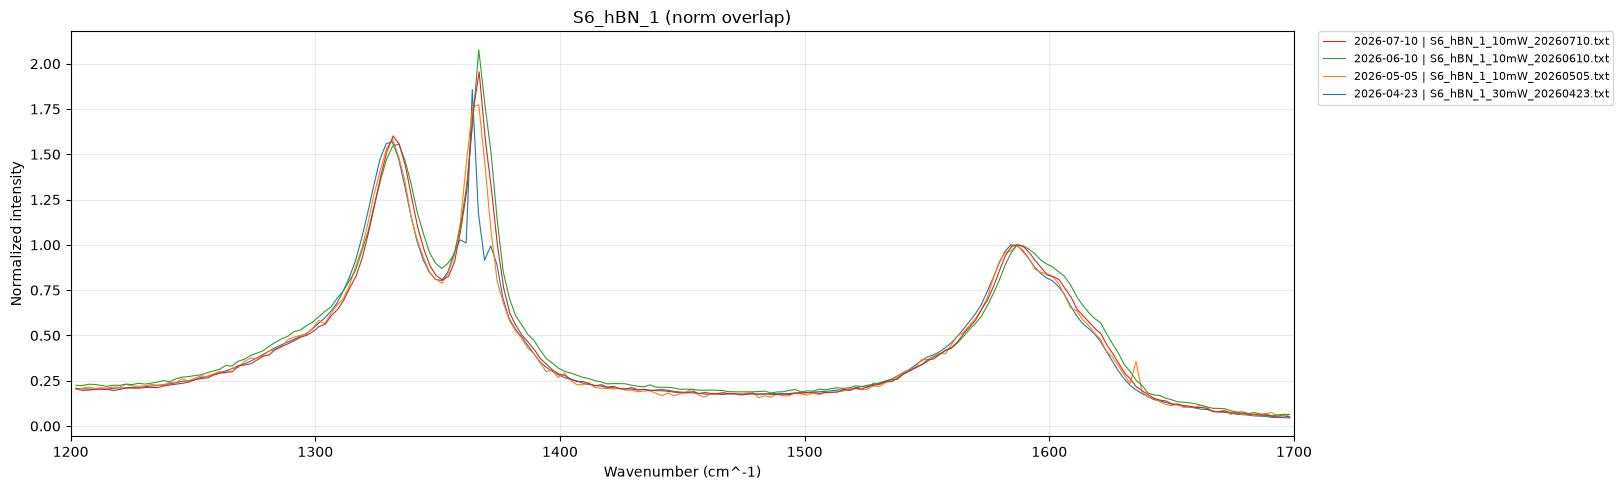

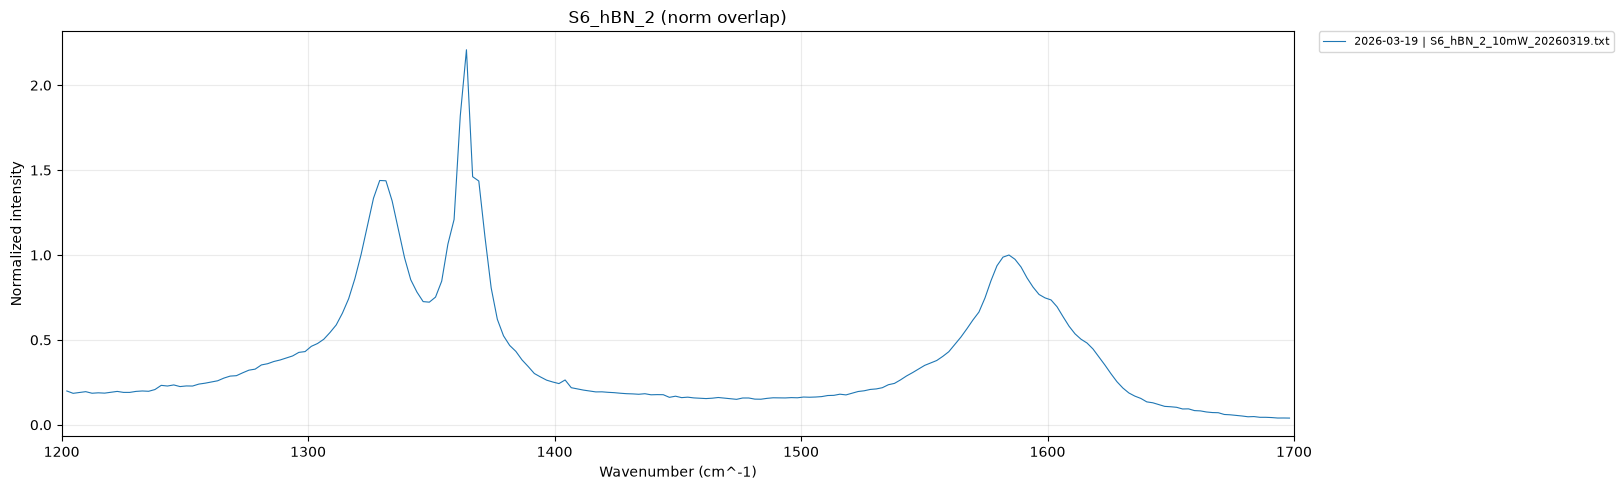

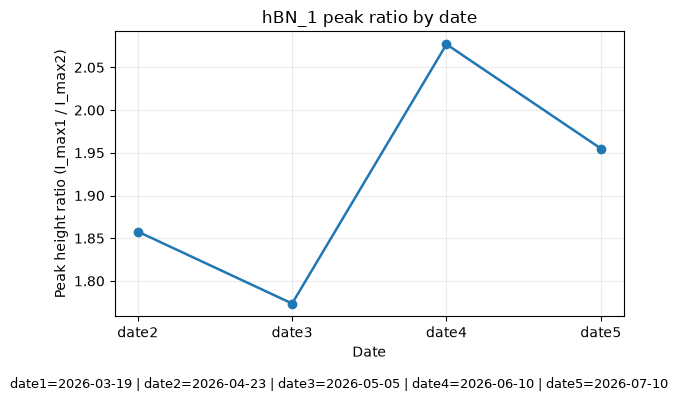

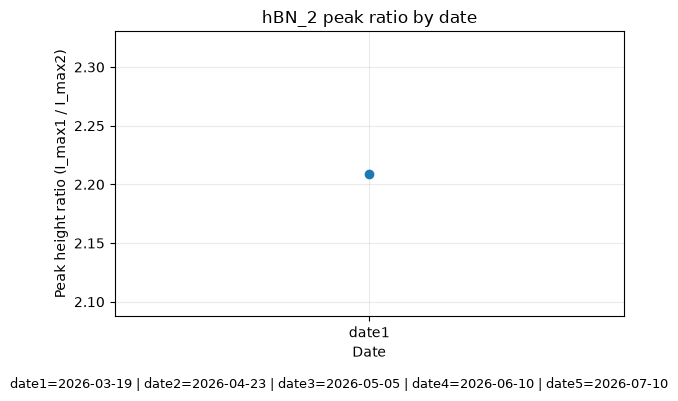

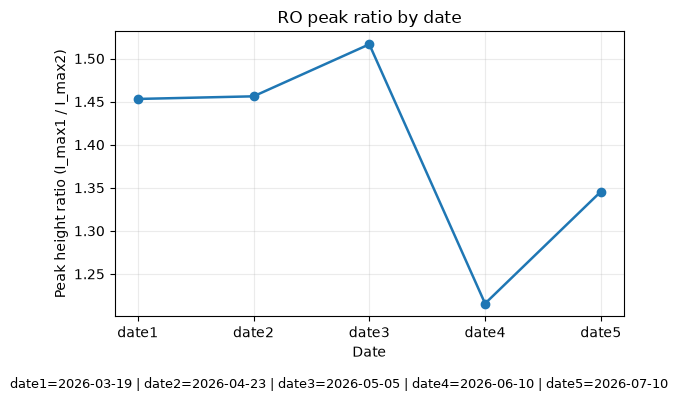

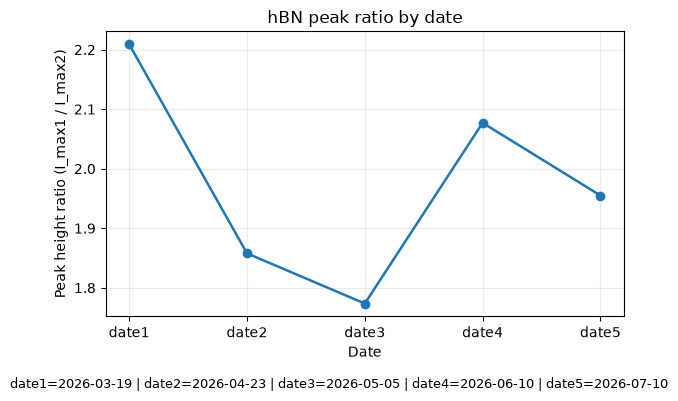

Map analysis exports written to: C:\Users\xuli\OneDrive - empa.ch\INT Lab 205 - 17AGNR_Xuanchen_Rafaela_Riya\02_Processed Raman data_ambient stability\S6_17AGNR_High cov_RO\S6_map_analysis_exports
Plot exports written under: C:\Users\xuli\OneDrive - empa.ch\INT Lab 205 - 17AGNR_Xuanchen_Rafaela_Riya\02_Processed Raman data_ambient stability\S6_17AGNR_High cov_RO\S6_map_analysis_exports\01_plots
Peak-ratio plots written to: C:\Users\xuli\OneDrive - empa.ch\INT Lab 205 - 17AGNR_Xuanchen_Rafaela_Riya\02_Processed Raman data_ambient stability\S6_17AGNR_High cov_RO\S6_map_analysis_exports\01_plots\04_peak_ratio\01_groups
Table exports written under: C:\Users\xuli\OneDrive - empa.ch\INT Lab 205 - 17AGNR_Xuanchen_Rafaela_Riya\02_Processed Raman data_ambient stability\S6_17AGNR_High cov_RO\S6_map_analysis_exports\03_tables
Code snapshots written under: C:\Users\xuli\OneDrive - empa.ch\INT Lab 205 - 17AGNR_Xuanchen_Rafaela_Riya\02_Processed Raman data_ambient stability\S6_17AGNR_High cov_RO\S6_

,file,group,date,pixels_available,pixels_used
0,S6_RO_20mW_20260319.txt,RO,2026-03-19,100,100
1,S6_RO_30mW_20260423.txt,RO,2026-04-23,100,100
2,S6_RO_20mW_20260505.txt,RO,2026-05-05,100,100
3,S6_RO_20mW_20260610.txt,RO,2026-06-10,100,100
4,S6_RO_20mW_20260710.txt,RO,2026-07-10,100,100
5,S6_hBN_1_30mW_20260423.txt,hBN,2026-04-23,64,64
6,S6_hBN_1_10mW_20260505.txt,hBN,2026-05-05,64,64
7,S6_hBN_1_10mW_20260610.txt,hBN,2026-06-10,64,64
8,S6_hBN_1_10mW_20260710.txt,hBN,2026-07-10,64,64
9,S6_hBN_2_10mW_20260319.txt,hBN,2026-03-19,100,100


,file,group,date,peak_count,peak1_wavenumber_cm1,peak1_intensity,peak2_wavenumber_cm1,peak2_intensity,peak_ratio
0,S6_RO_20mW_20260319.txt,RO,2026-03-19,8,1329.06,2510.426276,1584.37,1727.612054,1.453119
1,S6_RO_30mW_20260423.txt,RO,2026-04-23,7,1328.98,3552.350493,1586.73,2439.525300,1.456165
2,S6_RO_20mW_20260505.txt,RO,2026-05-05,6,1329.12,3763.248601,1584.39,2481.451548,1.516551
3,S6_RO_20mW_20260610.txt,RO,2026-06-10,6,1331.64,1438.013944,1599.01,1182.909576,1.215658
4,S6_RO_20mW_20260710.txt,RO,2026-07-10,7,1329.29,6960.515135,1586.99,5172.932246,1.345565
5,S6_hBN_1_30mW_20260423.txt,hBN,2026-04-23,6,1364.17,9238.775141,1584.29,4972.907725,1.857822
6,S6_hBN_1_10mW_20260505.txt,hBN,2026-05-05,10,1366.81,306.696869,1586.83,172.927281,1.773560
7,S6_hBN_1_10mW_20260610.txt,hBN,2026-06-10,8,1366.81,1218.013228,1586.83,586.421856,2.077026
8,S6_hBN_1_10mW_20260710.txt,hBN,2026-07-10,7,1366.98,1313.339280,1586.99,671.786677,1.954995
9,S6_hBN_2_10mW_20260319.txt,hBN,2026-03-19,9,1364.25,1421.658052,1584.37,643.590319,2.208949


In [21]:
import importlib

from IPython.display import display

import raman.config as cfg
import raman.core.analysis as rma
import raman.core.metadata as rmeta
import raman.export.csv_export
import raman.export.paths
import raman.export.snapshot as rexp
import raman.plotting.maps
import raman.plotting.spectra as rpl

cfg = importlib.reload(cfg)
rma = importlib.reload(rma)
rmeta = importlib.reload(rmeta)
importlib.reload(raman.export.paths)
importlib.reload(raman.export.csv_export)
importlib.reload(raman.plotting.maps)
rexp = importlib.reload(rexp)
rpl = importlib.reload(rpl)

# -----------------------------------------------------------------------------
# Stage 6: average each Raman map to one spectrum, split Au/hBN, sort by date
# Export plots as one file per group/subgroup with organized subfolders.
# -----------------------------------------------------------------------------
avg_map_preview = rma.build_average_map_spectra(
    parsed_collection=corrected_parsed_files,
    spectrum_key=cfg.SOURCE_SPECTRUM_KEY,
    keep_groups=cfg.MAP_GROUPS,
)
SAMPLE_NAME = rmeta.infer_sample_name(avg_map_preview)
MAP_ANALYSIS_OUTPUT_DIR = cfg.DATA_DIR / f"{SAMPLE_NAME}_map_analysis_exports"
PEAK_RATIO_PLOT_DIR = MAP_ANALYSIS_OUTPUT_DIR / "01_plots" / "04_peak_ratio" / "01_groups"
resolved_plot_ranges = rpl.resolve_plot_wavenumber_ranges(
    wavenumber_ranges=cfg.PLOT_WAVENUMBER_RANGES,
)
resolved_peak_ratio_ranges = rpl.resolve_plot_wavenumber_ranges(
    wavenumber_ranges=cfg.PEAK_RATIO_WAVENUMBER_RANGES,
)

average_visualized_corrected_parsed_files = rma.annotate_average_pixel_masks(
    parsed_collection=corrected_parsed_files,
    spectrum_key=cfg.SOURCE_SPECTRUM_KEY,
)

avg_map_spectra = rpl.plot_average_and_normalized_map_spectra(
    parsed_collection=average_visualized_corrected_parsed_files,
    spectrum_key=cfg.SOURCE_SPECTRUM_KEY,
    groups=cfg.MAP_GROUPS,
    normalization_method=cfg.NORMALIZATION_METHOD,
    normalization_peak_center_cm1=cfg.NORMALIZATION_PEAK_CENTER_CM1,
    normalization_peak_tolerance_cm1=cfg.NORMALIZATION_PEAK_TOLERANCE_CM1,
    raw_stack_scale=cfg.RAW_STACK_SCALE,
    raw_stack_extra_gap=cfg.RAW_STACK_EXTRA_GAP,
    norm_stack_scale=cfg.NORM_STACK_SCALE,
    norm_stack_extra_gap=cfg.NORM_STACK_EXTRA_GAP,
    wavenumber_ranges=cfg.PLOT_WAVENUMBER_RANGES,
    peak_ratio_wavenumber_ranges=cfg.PEAK_RATIO_WAVENUMBER_RANGES,
    output_dir=MAP_ANALYSIS_OUTPUT_DIR,
    sample_name=SAMPLE_NAME,
)

peak_ratio_df = rma.build_peak_ratio_table(
    avg_map_spectra=avg_map_spectra,
    spectrum_col="mean_spectrum",
    distance=15,
    wavenumber_min=resolved_peak_ratio_ranges[0]["wavenumber_min"],
    wavenumber_max=resolved_peak_ratio_ranges[0]["wavenumber_max"],
)

for peak_ratio_range in resolved_peak_ratio_ranges:
    peak_ratio_output_path = PEAK_RATIO_PLOT_DIR / "plot.png"
    if peak_ratio_range["export_stem_suffix"]:
        peak_ratio_output_path = peak_ratio_output_path.with_name(
            f"{peak_ratio_output_path.stem}_{peak_ratio_range['export_stem_suffix']}{peak_ratio_output_path.suffix}"
        )

    range_peak_ratio_df = rma.build_peak_ratio_table(
        avg_map_spectra=avg_map_spectra,
        spectrum_col="mean_spectrum",
        distance=15,
        wavenumber_min=peak_ratio_range["wavenumber_min"],
        wavenumber_max=peak_ratio_range["wavenumber_max"],
    )

    rpl.plot_peak_ratio_by_date(
        peak_ratio_df=range_peak_ratio_df,
        groups=cfg.MAP_GROUPS,
        output_path=peak_ratio_output_path,
    )

export_dir = rexp.export_stage6_outputs(
    data_dir=cfg.DATA_DIR,
    avg_map_spectra=avg_map_spectra,
    peak_ratio_df=peak_ratio_df,
    output_folder_name=f"{SAMPLE_NAME}_map_analysis_exports",
    sample_name=SAMPLE_NAME,
    corrected_parsed_files=average_visualized_corrected_parsed_files,
    cut_pixel_map_wavenumber_cm1=cfg.CUT_PIXEL_MAP_WAVENUMBER_CM1,
)

print(f"Map analysis exports written to: {export_dir}")
print(f"Plot exports written under: {export_dir / '01_plots'}")
print(f"Peak-ratio plots written to: {PEAK_RATIO_PLOT_DIR}")
print(f"Table exports written under: {export_dir / '03_tables'}")
print(f"Code snapshots written under: {export_dir / '04_code_snapshot'}")
display(avg_map_spectra[["file", "group", "date", "pixels_available", "pixels_used"]])
display(
    peak_ratio_df[
        [
            "file",
            "group",
            "date",
            "peak_count",
            "peak1_wavenumber_cm1",
            "peak1_intensity",
            "peak2_wavenumber_cm1",
            "peak2_intensity",
            "peak_ratio",
        ]

    ])

## Interactive Raman Map Explorer

Use the controls to compare map views across Stage 1 to Stage 6. Each stage appears once in the stage dropdown.

In [22]:
import importlib

import raman.config as cfg
import raman.plotting.explorer as rex
from raman.pipeline import build_explorer_stage_mappings

cfg = importlib.reload(cfg)
rex = importlib.reload(rex)

stage_collections, stage_spectrum_keys = build_explorer_stage_mappings(
    parsed_files=parsed_files,
    stage2_pixel_filtered_parsed_files=pixel_filtered_parsed_files,
    stage3_low_wavenumber_parsed_files=low_wavenumber_parsed_files,
    stage4_despiked_parsed_files=despiked_parsed_files,
    stage5_corrected_parsed_files=corrected_parsed_files,
    stage6_map_average_parsed_files=average_visualized_corrected_parsed_files,
)

viewer = rex.launch_raman_map_explorer(
    stage_collections=stage_collections,
    stage_spectrum_keys=stage_spectrum_keys,
    map_mode=cfg.EXPLORER_MAP_MODE,
)

In [23]:
import raman.export.snapshot as rexp

rexp = importlib.reload(rexp)

snapshot_path = rexp.save_explorer_snapshot(
    output_dir=cfg.EXPLORER_SNAPSHOT_DIR,
    stage_collections=stage_collections,
    stage_spectrum_keys=stage_spectrum_keys,
    map_mode=cfg.EXPLORER_MAP_MODE,
)
print(f"Explorer snapshot saved to: {snapshot_path}")

Explorer snapshot saved to: C:\Users\xuli\OneDrive - empa.ch\INT Lab 205 - 17AGNR_Xuanchen_Rafaela_Riya\02_Processed Raman data_ambient stability\S6_17AGNR_High cov_RO\explorer_snapshots\explorer_snapshot_20260820_103838.pkl.gz
